# LARRY data analysis

In [30]:
import json
from IPython.display import display, Markdown
import ipynbname

nb_path = ipynbname.path()
with open(nb_path) as f:
    nb = json.load(f)

all_headings = []
for cell in nb['cells']:
    if cell['cell_type'] == 'markdown':
        source = ''.join(cell['source'])
        if 'Table of Contents' in source:
            continue
        for line in source.split('\n'):
            line = line.strip()
            if line.startswith('#'):
                level = len(line) - len(line.lstrip('#'))
                title = line.lstrip('#').strip()
                all_headings.append((level, title))

min_level = min(h[0] for h in all_headings)
toc_lines = ["## Table of Contents\n Open outline or Ctrl+F to click\n"]
for level, title in all_headings:
    indent = '  ' * (level - min_level)
    toc_lines.append(f"{indent}- {title}")  # no link, just text

display(Markdown('\n'.join(toc_lines)))

## Table of Contents
 Open outline or Ctrl+F to click

- LARRY data analysis
    - Plot formatting
    - Path to data and output folders
    - Genes of interest
  - Prepare the data needed for analysis
- Identify DEG
    - Assign undifferentiated cells (day 2) cell-types based on future (day 4 and day 6) clonal cells' cell-type
  - Filter out known non-myeloid progenitors
  - Volcano plot
  - Assigning clone pair ids - every pair of cells with the same barcode is a "twin-par"
  - Comparing the twin vs random-pair PCA distance
    - Helper functions
    - Calculate the distances
    - Plot and save the boxplots
- Infer with TwINFER
  - Gene-gene correlation
    - Save the gene-gene correlation
  - Check for consistent correlated genes
  - Twinfer analysis - but replacing clonal pairs with random pairs
- GRNBoost analysis

### Import packages

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import tqdm
import scipy
import os
import sys
import joblib
import scanpy as sc
import os
import itertools
from itertools import product
from collections import defaultdict
from itertools import combinations
from scipy.stats import mannwhitneyu
from pathlib import Path
# from adjustText import adjust_text
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import json

/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Calculation functions
import importlib
import sys
import os

from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (

    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data,
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

In [ ]:
#needed for GrnBoost only (different conda env)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_score, recall_score, f1_score
from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score


### Plot formatting

In [3]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "fonts/Arial.ttf",
    "fonts/Arial Bold.ttf",
    "fonts/Arial Italic.ttf",
    "fonts/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: fonts/Arial.ttf
✔ Loaded font: fonts/Arial Bold.ttf
✔ Loaded font: fonts/Arial Italic.ttf
✔ Loaded font: fonts/Arial Bold Italic.ttf


In [ ]:
#colormap helper function

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = max(0, (0 - vmin) / (vmax - vmin))
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

### Path to data and output folders

In [4]:
data_path = "real_data/"
path_to_plots = f"/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5/"
# os.makedirs(path_to_plots, exist_ok=True)
path_to_plot_data = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_5/")
# path_to_plot_data.mkdir(exist_ok=True)

STDOUT:
 
STDERR:
 
Return code: 0


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


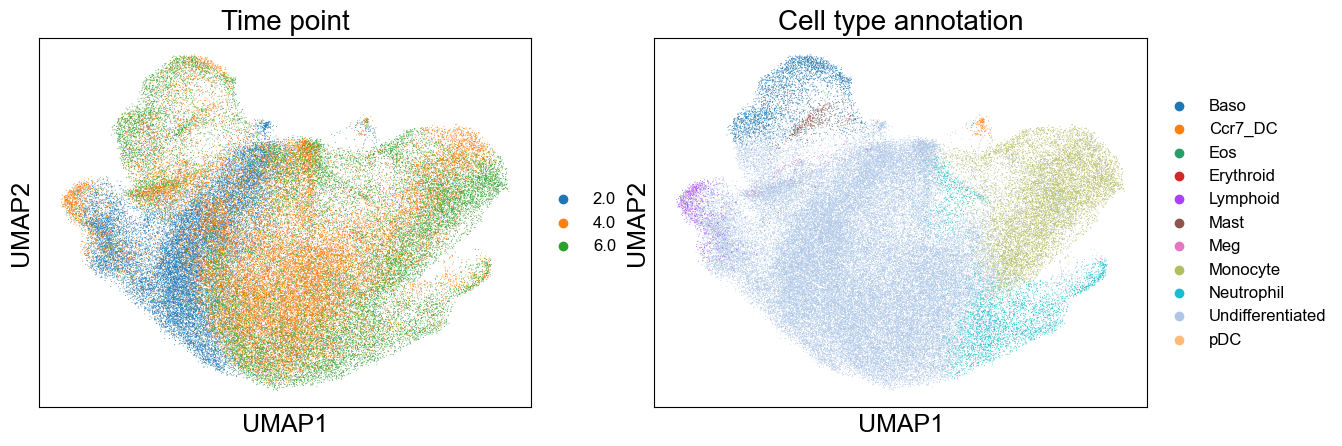

In [5]:
#Load the h5ad file
import subprocess
from pathlib import Path

repo = Path("/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER")

cmd = """
module load git-lfs
git lfs pull --include=real_data/LSK_d2_d4_d6.h5ad
"""

result = subprocess.run(
    ["bash", "-lc", cmd],
    cwd=repo,
    capture_output=True,
    text=True,
)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)

# Define the full path to the data file
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'
adata = sc.read_h5ad(file_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

### Genes of interest
- Neutrophil DEG from LARRY
- Monocyte DEG from LARRY
- TF involved in hematopoiesis from the 2011 paper

In [6]:
gene_list_Neutrophil = ['Muc13', 'Srgn', 'Ccl9', 'Plac8', 'Snrpf','Prtn3','Elane', 'Igfbp4', 'Ap3s1', 'Ctsg'] #Neutrophil
gene_list_Monocyte = ['Rbms1', 'Tuba1b','Sirpa', 'Ttf1', 'H3f3b', 'Set', 'Tk1', 'Fkbp4', 'Hspd1', 'Emb'] #Monocyte
gene_list_Regulator_TF = ['Gata1', 'Gata2', 'Gfi1', 'Fli1', 'Spi1', 'Tal1',  'Cebpa', 'Jun', 'Egr1', 'Nab2', 'Klf1', 'Zfpm1'] #TF involved in hematopoiesis regulation

In [7]:
#Check that all of these genes are present in the dataset (since sometimes they have alternate names. E.g. Pu1 is names Spi1)
gene_list_check = gene_list_Neutrophil + gene_list_Monocyte + gene_list_Regulator_TF

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)

print("❌ Not found in dataset", not_found)

Found 32 genes out of 32
✅ Found gene(s): ['muc13', 'srgn', 'ccl9', 'plac8', 'snrpf', 'prtn3', 'elane', 'igfbp4', 'ap3s1', 'ctsg', 'rbms1', 'tuba1b', 'sirpa', 'ttf1', 'h3f3b', 'set', 'tk1', 'fkbp4', 'hspd1', 'emb', 'gata1', 'gata2', 'gfi1', 'fli1', 'spi1', 'tal1', 'cebpa', 'jun', 'egr1', 'nab2', 'klf1', 'zfpm1']
❌ Not found in dataset []


In [8]:
#Gene set to use for current analysis
gene_set_name = "Regulator_TF" #For Neutrophils, modify this to Neutrophil
curr_gene_list = gene_list_Regulator_TF #For neutrophil, modify this to gene_list_Neutrophil
gene_subset = [s + '_mRNA' for s in curr_gene_list]

## Prepare the data needed for analysis

- Undifferentiated cells to identify DEG genes before differentiation
- All cells present at each time point to calculate gene correlations
- Twin/Clonal pairs at each time point and across timepoints (t1 cells can be either all cells or only undifferentiated cells)
- Random pairs of cells at each time point

In [9]:
t1 = 2
t2 = 4
t3 = 6

In [10]:
#Subset the data into different time points - includes both barcoded and not barcoded cells (hence, all)
adata.obs['cell_id'] = adata.obs.index
adata_t1_all = adata[(adata.obs['Time point'] == t1)].copy()
adata_t2_all = adata[(adata.obs['Time point'] == t2)].copy()
adata_t3_all = adata[(adata.obs['Time point'] == t3)].copy()

In [11]:
# All cells at time t1 to calculate gene correlation
def make_all_cells_table(adata_t, timepoint, gene_subset, curr_gene_list):
    df = pd.DataFrame({
        'clone_id': adata_t.obs['clone_id'].values,
        'cell_id': adata_t.obs['cell_id'].values,
    })

    # dummy but consistent fields to match twin format
    df['pair_id'] = df['cell_id'].astype(str) + f"_single_{timepoint}"
    df['replicate'] = 1
    df['time_step'] = timepoint

    # add expression
    df[gene_subset] = adata_t[df.cell_id, curr_gene_list].X.toarray()

    return df

gene_subset = [s + '_mRNA' for s in curr_gene_list]
t1_data_all_cells = make_all_cells_table(
    adata_t1_all, t1, gene_subset, curr_gene_list
)
t2_data_all_cells = make_all_cells_table(
    adata_t2_all, t2, gene_subset, curr_gene_list
)
t3_data_all_cells = make_all_cells_table(
    adata_t3_all, t3, gene_subset, curr_gene_list
)

In [ ]:
#Identifying barcoded cells at time t1
adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()
adata_t1_clones_undiff = adata_t1[adata_t1.obs['Cell type annotation'] == 'Undifferentiated']

# Print the results
print(f"Number of barcoded cells: {adata_t1.shape[0]}")
print(f"Number of undifferentiated barcoded cells: {adata_t1_clones_undiff.shape[0]}")

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Identify DEG

### Assign undifferentiated cells (day 2) cell-types based on future (day 4 and day 6) clonal cells' cell-type

In [ ]:
# Initialize dictionary to store cell type counts and percentages for each clone_id
clone_cell_type = {}

# Loop through each unique clone_id
for clone_id in adata_t1_clones_undiff.obs.clone_id.unique():
    # Get unique cell types for t2 and t3 as lists
    unique_t2_cell_types = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()
    unique_t3_cell_types = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()

    # Concatenate the lists and convert to a set (to avoid duplicates)
    cell_type = set(unique_t2_cell_types + unique_t3_cell_types)
    if len(cell_type) < 1:
        continue

    # Get the number of cells for each cell type at t2 and t3
    t2_cell_counts = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()
    t3_cell_counts = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()

    # Initialize dictionary to store counts and percentages
    cell_type_info = {}

    # Count and calculate percentages for t2
    total_cells_t2 = len(adata_t2[adata_t2.obs.clone_id == clone_id])
    for cell in cell_type:
        t2_count = t2_cell_counts.get(cell, 0)
        t2_percentage = (t2_count / total_cells_t2) * 100 if total_cells_t2 > 0 else 0
        cell_type_info[cell] = {'t2_count': t2_count, 't2_percentage': t2_percentage}

    # Count and calculate percentages for t3
    total_cells_t3 = len(adata_t3[adata_t3.obs.clone_id == clone_id])
    for cell in cell_type:
        t3_count = t3_cell_counts.get(cell, 0)
        t3_percentage = (t3_count / total_cells_t3) * 100 if total_cells_t3 > 0 else 0
        if cell in cell_type_info:
            cell_type_info[cell].update({'t3_count': t3_count, 't3_percentage': t3_percentage})
        else:
            cell_type_info[cell] = {'t3_count': t3_count, 't3_percentage': t3_percentage}

    # Store the information in the dictionary
    clone_cell_type[clone_id] = cell_type_info

# Convert the dictionary into a pandas DataFrame for easier inspection
cell_type_df = pd.DataFrame.from_dict({(clone_id, cell_type): values
                                       for clone_id, clone_info in clone_cell_type.items()
                                       for cell_type, values in clone_info.items()},
                                      orient='index')

# Display the DataFrame
print(cell_type_df)

In [ ]:
# --------------------------------------------------
# 0. Sanity check: confirm index structure
# --------------------------------------------------
print("Index names:", cell_type_df.index.names)
# Expected: ['clone_id', 'cell_type']

# --------------------------------------------------
# 1. Count cell-type multiplicity per clone (t2 ∪ t3)
# --------------------------------------------------
n_cell_types_per_clone = (
    cell_type_df
    .query("(t2_percentage > 0) or (t3_percentage > 0)")
    .groupby(level=0)   # level 0 = clone_id
    .size()             # one row per cell type → count = multiplicity
)

# --------------------------------------------------
# 24. Histogram
# --------------------------------------------------
plt.figure(figsize=(5, 4))
plt.hist(
    n_cell_types_per_clone,
    bins=range(1, n_cell_types_per_clone.max() + 2),
    align="left",
    edgecolor="black"
)
plt.xlabel("Number of cell types per clone")
plt.ylabel("Number of clones")
plt.title(r"Cell-type multiplicity per clone (t2 $\cup$ t3)")
plt.tight_layout()
plt.show()


In [17]:
consistent_corr

[('Cebpa', 'Gfi1'),
 ('Cebpa', 'Spi1'),
 ('Cebpa', 'Tal1'),
 ('Egr1', 'Gata2'),
 ('Gata1', 'Gata2'),
 ('Gata2', 'Klf1'),
 ('Gata2', 'Tal1'),
 ('Gfi1', 'Spi1'),
 ('Jun', 'Spi1')]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Assumptions
# --------------------------------------------------
# cell_type_df:
#   MultiIndex (clone_id, cell_type)
#   columns: t2_percentage, t3_percentage
#
# Definition:
#   For each cell type, use the percentage at the timepoint
#   where it occurs (t2 or t3). If it occurs at both, take max.

# --------------------------------------------------
# Get cell types
# --------------------------------------------------
cell_types = cell_type_df.index.get_level_values(1).unique()

# --------------------------------------------------
# Set up subplot grid
# --------------------------------------------------
n_types = len(cell_types)
n_cols = 4
n_rows = int(np.ceil(n_types / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 2.8 * n_rows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

# --------------------------------------------------
# Loop over cell types
# --------------------------------------------------
for ax, ct in zip(axes, cell_types):

    df_ct = cell_type_df.xs(ct, level=1)

    # Use the percentage where the cell type occurs
    pct = df_ct[["t2_percentage", "t3_percentage"]].max(axis=1)

    # Keep only clones where it actually appears
    pct = pct[pct > 0]

    ax.hist(
        pct,
        bins=np.linspace(0, 100, 21),
        edgecolor="black"
    )

    ax.set_title(ct)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage of clone (%)")
    ax.set_ylabel("Number of clones")
    ax.set_yscale('log')
# Turn off unused axes
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle(
    r"Within-clone percentage distribution of each cell type (t2 $\cup$ t3)",
    y=1.02, fontsize = 20
)

plt.tight_layout()
plt.show()


In [ ]:
clone_dominant_cell_type = {}
clone_cell_type_composition = {}
count = 0
for clone_id, cell_type_info in clone_cell_type.items():

    # --- compute max at each time ---
    max_t2 = max(info["t2_percentage"] for info in cell_type_info.values())
    max_t3 = max(info["t3_percentage"] for info in cell_type_info.values())

    dom_t2 = sorted([
        ct for ct, info in cell_type_info.items()
        if info["t2_percentage"] == max_t2
    ])

    dom_t3 = sorted([
        ct for ct, info in cell_type_info.items()
        if info["t3_percentage"] == max_t3
    ])


    # --- choose timepoint ---
    if max_t3 > max_t2:
        chosen_types = dom_t3
        time_key = "t3_percentage"

    elif max_t2 > max_t3:
        # t2 wins unless it is purely Undifferentiated
        if dom_t2 == ["Undifferentiated"] and max_t3 > 0:
            count +=1
            chosen_types = dom_t3
            time_key = "t3_percentage"
        else:
            chosen_types = dom_t2
            time_key = "t2_percentage"

    else:  # equal max
        chosen_types = dom_t3
        time_key = "t3_percentage"

    # --- resolve ties ---
    if len(chosen_types) > 1:
        non_undiff = [ct for ct in chosen_types if ct != "Undifferentiated"]
        if len(non_undiff) > 0:
            chosen_types = non_undiff
        # else: keep Undifferentiated

    # --- final assignment (SCALAR ONLY) ---
    dominant_type = chosen_types[0] if len(chosen_types) > 0 else None
    clone_dominant_cell_type[clone_id] = dominant_type

    # --- composition string ---
    composition_parts = []
    for ct, info in cell_type_info.items():
        pct = info[time_key]
        if pct > 0:
            composition_parts.append(f"{ct}: {pct:.0f}%")

    clone_cell_type_composition[clone_id] = ", ".join(composition_parts)

# Now, assign the dominant cell type(s) to each clone in adata.obs
adata_t1_clones_undiff.obs["dominant_cell_type"] = None
adata_t1_clones_undiff.obs["cell_type_composition"] = None

for clone_id, dom_type in clone_dominant_cell_type.items():
    adata_t1_clones_undiff.obs.loc[
        adata_t1_clones_undiff.obs.clone_id == clone_id,
        "dominant_cell_type"
    ] = dom_type

    adata_t1_clones_undiff.obs.loc[
        adata_t1_clones_undiff.obs.clone_id == clone_id,
        "cell_type_composition"
    ] = clone_cell_type_composition[clone_id]

# How many got None?
print(
    adata_t1_clones_undiff.obs["dominant_cell_type"]
    .isna()
    .sum()
)
print(count)

In [ ]:
# --------------------------------------------------
# Get clone -> dominant cell type mapping
# --------------------------------------------------
clone_to_dom = (
    adata_t1_clones_undiff.obs
    .dropna(subset=["dominant_cell_type"])
    .drop_duplicates(subset=["clone_id"])
    .set_index("clone_id")["dominant_cell_type"]
)

# --------------------------------------------------
# Get list of dominant cell types
# --------------------------------------------------
dominant_cell_types = sorted(clone_to_dom.unique())

# --------------------------------------------------
# Set up subplot grid
# --------------------------------------------------
n_types = len(dominant_cell_types)
n_cols = 4
n_rows = int(np.ceil(n_types / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 2.8 * n_rows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

# --------------------------------------------------
# Loop over dominant cell types
# --------------------------------------------------
for ax, ct in zip(axes, dominant_cell_types):

    # clones where this cell type is dominant
    clones_ct = clone_to_dom[clone_to_dom == ct].index

    # SAFE extraction (no KeyError)
    df_ct_all = cell_type_df.xs(ct, level=1, drop_level=False)
    df_ct = df_ct_all.loc[
        df_ct_all.index.get_level_values(0).isin(clones_ct)
    ]

    if df_ct.empty:
        ax.axis("off")
        continue

    # dominant percentage
    pct = df_ct[["t2_percentage", "t3_percentage"]].max(axis=1)

    ax.hist(
        pct,
        bins=np.linspace(0, 100, 21),
        edgecolor="black"
    )

    ax.set_title(ct)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage of clone (%)")
    ax.set_ylabel("Number of clones")
    ax.set_yscale("log")

# Turn off unused axes
for ax in axes[len(dominant_cell_types):]:
    ax.axis("off")

plt.suptitle(
    "Within-clone percentage of dominant cell type",
    y=1.02, fontsize = 20
)

plt.tight_layout()
plt.show()

In [ ]:
# Get unique cell types INCLUDING None
cell_type_list = adata_t1_clones_undiff.obs['dominant_cell_type'].unique()

# Print the total number of cells
print(f"Number of cells: {adata_t1_clones_undiff.shape[0]}")

# Print the number of cell types and list them
print(f"Number of cell types (including None): {len(cell_type_list)}")
print(f"Cell types: {cell_type_list}")

# Count number of cells per dominant cell type INCLUDING None
cell_type_counts = (
    adata_t1_clones_undiff.obs['dominant_cell_type']
    .value_counts(dropna=False)
)

# Print counts
for cell_type, count in cell_type_counts.items():
    print(f"{cell_type}: {count}")

## Filter out known non-myeloid progenitors

In [18]:
lymphoid_cells = ['Lymphoid']
adata_t1_clones_undiff_filter = adata_t1_clones_undiff[~adata_t1_clones_undiff.obs['dominant_cell_type'].isin(lymphoid_cells)]

## Volcano plot

In [19]:
def volcano_plot(
    adata,
    groupby,
    group,
    genes,
    pval_threshold=0.05,
    gene_list_Neutrophil=[],
    gene_list_monocyte=[],
    gene_list_ubi_exp=[]
    ):

    # -----------------------------
    # Subset data
    # -----------------------------
    adata_group1 = adata[adata.obs[groupby] == group]
    adata_group2 = adata[adata.obs[groupby] != group]

    logfc_list, pval_list, gene_group_list = [], [], []
    mean_g1_list, mean_g2_list = [], []

    for gene in genes:
        expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
        expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()

        mean_group1 = np.mean(expr_group1)
        mean_group2 = np.mean(expr_group2)

        logfc = np.log2((mean_group1 + 1) / (mean_group2 + 1))
        logfc_list.append(logfc)
        mean_g1_list.append(mean_group1)
        mean_g2_list.append(mean_group2)

        _, pval = mannwhitneyu(expr_group1, expr_group2, alternative="two-sided")
        pval_list.append(pval)

        if gene in gene_list_Neutrophil:
            gene_group_list.append("Neutrophil")
        elif gene in gene_list_monocyte:
            gene_group_list.append("Monocyte")
        elif gene in gene_list_ubi_exp:
            gene_group_list.append("TF")
        else:
            gene_group_list.append("More TF")

    # -----------------------------
    # Results DataFrame
    # -----------------------------
    df_results = pd.DataFrame({
        "gene": genes,
        "mean_g1": mean_g1_list,
        "mean_g2": mean_g2_list,
        "logFC": logfc_list,
        "pval": pval_list,
        "gene_group": gene_group_list
    })

    df_results["neg_log10_pval"] = -np.log10(df_results["pval"] + 1e-10)
    df_results["significant"] = df_results["pval"] <= pval_threshold

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    # Non-significant (grey)
    sns.scatterplot(
        data=df_results[~df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        style="gene_group",
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "TF": "^",
            "More TF": "X"
        },
        color="lightgray",
        edgecolor=None,
        legend=False,
        clip_on=False,
        ax=ax
    )

    # Significant (colored)
    sns.scatterplot(
        data=df_results[df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        hue="gene_group",
        style="gene_group",
        palette={
            "Neutrophil": "#56B4E9",
            "Monocyte": "#CC79A7",
            "TF": "#009E73",
            "More TF": "gray"
        },
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "TF": "^",
            "More TF": "X"
        },
    edgecolor='none', 
    linewidth=0,       
    clip_on=False,
    ax=ax
    )

    # -----------------------------
    # Text labels (no clipping)
    # -----------------------------
    texts = []
    for _, row in df_results[df_results["significant"]].iterrows():
        texts.append(
            ax.text(
                row["logFC"],
                row["neg_log10_pval"],
                row["gene"],
                fontsize=14,
                clip_on=False
            )
        )

    adjust_text(
    texts,
    ax=ax,
    move_only={'text': 'xy'},  
    expand_text=(1.1, 1.1),    
    expand_points=(1.0, 1.0),  
    force_text=(0.1, 0.4),      
    )

    # -----------------------------
    # Threshold line
    # -----------------------------
    ax.axhline(
        y=-np.log10(pval_threshold),
        color="green",
        linestyle="--",
        clip_on=False
    )

    # -----------------------------
    # Styling
    # -----------------------------
    sns.despine(ax=ax, right=True, top=True)
    ax.set_title(f"{group} vs rest")
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 p-value")

    ax.legend(
        title="Gene Groups",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )
    plt.show()

    return df_results

In [ ]:
df_volcano_plot = {}
genes = gene_list_50_genes
cell_type_list = ["Neutrophil", "Monocyte"]
for cell_type in cell_type_list:
  if cell_type == "None":
    continue
  df_volcano_plot[cell_type] = volcano_plot(adata_t1_clones_undiff_filter, groupby='dominant_cell_type', group=cell_type, genes = genes, pval_threshold=0.05, gene_list_Neutrophil=[], gene_list_monocyte = [], gene_list_ubi_exp=[])
for cell_type in df_volcano_plot.keys():
    df = df_volcano_plot[cell_type]
    df.to_csv(f"{path_to_plot_data}/volcano_plot_{cell_type}_myeloid_50_genes.csv")
    print("saved")

## Assigning clone pair ids - every pair of cells with the same barcode is a "twin-par"

In [ ]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff_filter.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()

#Remove any lymphoid-lineage cells
lymphoid_cells = ['Lymphoid', 'pDC']
adata_t2 = adata_t2[~adata_t2.obs['Cell type annotation'].isin(lymphoid_cells)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3[~adata_t3.obs['Cell type annotation'].isin(lymphoid_cells)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

## Comparing the twin vs random-pair PCA distance

### Helper functions

In [25]:
# ============================
#   1. Distance computation
# =============
# ===============
def compute_distances(adata):
    """
    Compute pairwise transcriptomic distances assuming cells are sorted
    in twin order: (cell0_A, cell0_B, cell1_A, cell1_B, ...)
    and that each consecutive pair belongs to the same clone.
    """
    pca = adata.obsm['X_pca']
    clone_ids = adata.obs['clone_id'].values

    # sanity check: even number of cells
    if pca.shape[0] % 2 != 0:
        raise ValueError("Number of cells must be even for twin pairing.")

    # check clone_id matching
    clone_left  = clone_ids[::2]
    clone_right = clone_ids[1::2]

    if not np.all(clone_left == clone_right):
        bad = np.where(clone_left != clone_right)[0]
        raise ValueError(
            f"Found {len(bad)} twin pairs with mismatched clone_id. "
            f"First few bad indices: {bad[:5]}"
        )

    # compute distances
    deltas = pca[::2] - pca[1::2]
    return np.linalg.norm(deltas, axis=1)


# ============================
#   2. Significance symbols
# ============================
def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

# ============================
#   3. Stat annotation for boxplots
# ============================
def add_stat_annotation(ax, category_a, category_b, label, subset,
                        y_offset=0.05, level=0):
    """
    Draws a significance bracket ABOVE vertical boxplots with clip turned OFF.
    """

    # X-axis category names
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    if category_a not in xticklabels or category_b not in xticklabels:
        return

    x1 = xticklabels.index(category_a)
    x2 = xticklabels.index(category_b)
    x_min, x_max = min(x1, x2), max(x1, x2)

    # Height for bracket
    ymax = subset['Transcriptomic distance [a.u.]'].max()
    h = ymax * (1 + y_offset + level * 0.12)

    # Bracket line (no clipping)
    ax.plot(
        [x_min, x_min, x_max, x_max],
        [h, h * 1.05, h * 1.05, h],
        lw=1.5,
        color='black',
        clip_on=False
    )

    # Label (no clipping)
    ax.text(
        (x_min + x_max) / 2,
        h * 1.12,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        clip_on=False
    )

def plot_vertical_boxplots(df_distances, save_dir = None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    # plt.subplots_adjust(top=0.83)  # Ensure title + brackets never clip

    timepoints = ['Day 2', 'Day 4', 'Day 6']

    for ax, timepoint in zip(axes, timepoints):

        subset = df_distances[df_distances['timepoint'] == timepoint]

        # -----------------------------
        # Vertical boxplot
        # -----------------------------
        bp = sns.boxplot(
            data=subset,
            x='pair_type',
            y='Transcriptomic distance [a.u.]',
            hue='pair_type',
            palette={'clonal pairs': 'lightgray', 'random pairs': 'gray'},
            ax=ax
        )

        # Disable clipping for every boxplot artist
        for artist in ax.artists + ax.lines:
            artist.set_clip_on(False)

        sns.despine(right=True, top=True, ax=ax)

        ax.set_xlabel('')
        ax.set_ylabel('transcriptomic distance [a.u.]')
        ax.set_title(timepoint, pad=30)  # higher title
        ax.set_ylim(0,62)
        # -----------------------------
        # Mann-Whitney U-test
        # -----------------------------
        clonal = subset[subset['pair_type'] == 'clonal pairs']['Transcriptomic distance [a.u.]']
        random = subset[subset['pair_type'] == 'random pairs']['Transcriptomic distance [a.u.]']

        _, pval = mannwhitneyu(clonal, random, alternative='two-sided')
        label = get_significance_symbol(pval)
        # # -----------------------------
        # # Add significance bracket
        # # -----------------------------
        add_stat_annotation(
            ax=ax,
            category_a='clonal pairs',
            category_b='random pairs',
            label=label,
            subset=subset,
            y_offset=0.05,
            level=0
        )


    # Legend outside (no clipping)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.svg'),
                    format='svg',
                    facecolor='none', edgecolor='none', transparent=True)
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.pdf'),
                    format='pdf',
                    facecolor='none', edgecolor='none', transparent=True)

### Calculate the distances

In [ ]:
# Compute distances in PC space
distances_t1 = compute_distances(adata_t1[t1_data.cell_id])
distances_t2 = compute_distances(adata_t2[t2_data.cell_id])
distances_t3 = compute_distances(adata_t3[t3_data.cell_id])

distances_across_t = adata_t1[across_t_data_t1.cell_id].obsm['X_pca'] - adata_t2[across_t_data_t2.cell_id].obsm['X_pca']
distances_across_t = np.linalg.norm(distances_across_t, axis=1)

# Random
np.random.seed(42)

def random_distances(adata, n_pairs):
    idx = np.arange(adata.n_obs)
    pairs = np.random.choice(idx, size=(n_pairs, 2), replace=True)
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]
    while pairs.shape[0] < n_pairs:
        extra = np.random.choice(idx, size=(n_pairs - pairs.shape[0], 2), replace=True)
        extra = extra[extra[:, 0] != extra[:, 1]]
        pairs = np.vstack([pairs, extra])
    return np.linalg.norm(adata.obsm["X_pca"][pairs[:, 0]] - adata.obsm["X_pca"][pairs[:, 1]], axis=1)

distances_random_t1 = random_distances(adata_t1, len(distances_t1))
distances_random_t2 = random_distances(adata_t2, len(distances_t2))
distances_random_t3 = random_distances(adata_t3, len(distances_t3))



# Create dataframe for plotting
df_distances = pd.DataFrame({
    'Transcriptomic distance [a.u.]': np.concatenate([distances_t1, distances_t2, distances_t3,
                                distances_random_t1, distances_random_t2, distances_random_t3]),
    'pair_type': (['clonal pairs'] * len(distances_t1) +
                  ['clonal pairs'] * len(distances_t2) +
                  ['clonal pairs'] * len(distances_t3) +
                  ['random pairs'] * len(distances_random_t1) +
                  ['random pairs'] * len(distances_random_t2) +
                  ['random pairs'] * len(distances_random_t3)),
    'timepoint': (['Day 2'] * len(distances_t1) +
                  ['Day 4'] * len(distances_t2) +
                  ['Day 6'] * len(distances_t3) +
                  ['Day 2'] * len(distances_random_t1) +
                  ['Day 4'] * len(distances_random_t2) +
                  ['Day 6'] * len(distances_random_t3))
})

### Plot and save the boxplots

In [ ]:
plot_vertical_boxplots(df_distances, save_dir = None)
df_distances.to_csv(f"{path_to_plot_data}twin_vs_random_dist.csv")

# Infer with TwINFER

In [25]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_measurements = (
    pd.concat([t1_twins, across_t_twin1], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t2_measurements = (
    pd.concat([t2_twins, across_t_twin2], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t3_measurements = t3_twins.drop_duplicates(subset="cell_id", keep="first")

In [ ]:
# Sets of cell IDs
t1_twin_cells = set(t1_twins["cell_id"])
t1_across_cells = set(across_t_twin1["cell_id"])

t2_twin_cells = set(t2_twins["cell_id"])
t2_across_cells = set(across_t_twin2["cell_id"])

# Overlaps
overlap_t1 = t1_twin_cells & t1_across_cells
overlap_t2 = t2_twin_cells & t2_across_cells

print("T1 overlap (t1 ∩ across):", len(overlap_t1))
print("T2 overlap (twin ∩ across):", len(overlap_t2))


## Gene-gene correlation

In [27]:
# Define input parameters
plot_correlation_matrices_as_heatmap = True
have_any_output = False
p_val_threshold_scrambled_gene_correlation = 0.02
show_scrambled_distribution_gene_correlation = True
z_score_threshold_two_states = 10
n_shuffles=10000


In [ ]:
# # --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t1 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t1_measurements, curr_gene_list
)
print(pairwise_gene_gene_correlation_matrix_t1)
no_regulation_t1, potential_regulation_t1, threshold, _ = check_gene_gene_correlation_threshold(
    all_t1_measurements, pairwise_gene_gene_correlation_matrix_t1, curr_gene_list, n_shuffles = n_shuffles, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=10
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations for {gene_set_name} - day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self=True
    )

In [42]:
pairwise_gene_gene_correlation_matrix_t1.to_csv("pairwise_gene_gene_correlation_matrix_t1.csv")

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at t2: day 4 ---
pairwise_gene_gene_correlation_matrix_t2 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t2_measurements, curr_gene_list
)
no_regulation_t2, potential_regulation_t2, _, _= check_gene_gene_correlation_threshold(
    all_t2_measurements, pairwise_gene_gene_correlation_matrix_t2, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=19
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Gene-gene correlations for {gene_set_name} - day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at
# 
#  t3: day 6 ---
pairwise_gene_gene_correlation_matrix_t3 = calculate_pairwise_gene_gene_correlation_matrix(
    t3_data_all_cells, curr_gene_list
)
no_regulation_t3, potential_regulation_t3, _, _ = check_gene_gene_correlation_threshold(
    t3_data_all_cells, pairwise_gene_gene_correlation_matrix_t3, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=19
)

if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t3, potential_regulation=potential_regulation_t3,
        title=f"Gene-gene correlations for {gene_set_name}", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

### Save the gene-gene correlation

In [ ]:
# === Combine and save all timepoint results ===
rows = []

for tp, (no_reg, pot_reg, corr_mat) in {
    "t1": (no_regulation_t1, potential_regulation_t1, pairwise_gene_gene_correlation_matrix_t1),
    "t2": (no_regulation_t2, potential_regulation_t2, pairwise_gene_gene_correlation_matrix_t2),
    "t3": (no_regulation_t3, potential_regulation_t3, pairwise_gene_gene_correlation_matrix_t3),
}.items():

    all_pairs = set(tuple(sorted(p)) for p in no_reg + pot_reg)

    for g1, g2 in all_pairs:
        # lookup correlation (try both orders)
        if g1 in corr_mat.index and g2 in corr_mat.columns:
            corr_val = corr_mat.loc[g1, g2]
        elif g2 in corr_mat.index and g1 in corr_mat.columns:
            corr_val = corr_mat.loc[g2, g1]
        else:
            corr_val = None

        pair_sorted = tuple(sorted((g1, g2)))
        if pair_sorted in [tuple(sorted(p)) for p in pot_reg]:
            category = "potential_regulation"
        elif pair_sorted in [tuple(sorted(p)) for p in no_reg]:
            category = "no_regulation"
        else:
            category = "uncategorized"

        rows.append([g1, g2, corr_val, category, tp])

# Create DataFrame
df = pd.DataFrame(rows, columns=["gene_1", "gene_2", "correlation", "category", "timepoint"])

# Define output filename with timestamp
outfile = path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv"

# Save file
df.to_csv(outfile, index=False)

# Print confirmation with readable date/time
print(f"Saved {len(df)} pairs to {outfile.name}")

In [15]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")


t1: 53 no-reg pairs, 13 potential-reg pairs, matrix (12, 12)
t2: 39 no-reg pairs, 27 potential-reg pairs, matrix (12, 12)
t3: 13 no-reg pairs, 53 potential-reg pairs, matrix (12, 12)


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap(corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)

In [ ]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# # --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, potential_regulation_t2, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

In [ ]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [ ]:
# --- Step 4: Print summary of results ---
all_gene_pairs = list(product(curr_gene_list, repeat=2))
if have_any_output:
    print_summary(no_regulation_t1, single_state_regulation_t1, multiple_states_no_reg, multiple_states_and_reg)

In [48]:
# ----------------------------------
# Collect all classified pairs
# ----------------------------------
scenario_pair_lists = {
    "single-state, no regulation": no_regulation_t2,
    "single-state, regulation": single_state_regulation_t2,
    "multiple states":multiple_states_gene_pairs_t2
}

records = []

for scenario, pairs in scenario_pair_lists.items():
    for g1, g2 in pairs:
        g1, g2 = sorted((g1, g2))   # normalize
        records.append({
            "gene_1": g1,
            "gene_2": g2,
            "scenario": scenario,
            "timepoint": "t2"        # optional but strongly recommended
        })

df_pair_classification = pd.DataFrame(records)

# sanity check
assert not df_pair_classification.duplicated(
    ["gene_1", "gene_2", "timepoint"]
).any()

df_pair_classification.to_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}_day_4.csv")

In [38]:
# ----------------------------------
# Collect all classified pairs
# ----------------------------------
scenario_pair_lists = {
    "single-state, no regulation": no_regulation_t1,
    "single-state, regulation": single_state_regulation_t1,
    "multiple states": multiple_states_no_reg + multiple_states_and_reg
}

records = []

for scenario, pairs in scenario_pair_lists.items():
    for g1, g2 in pairs:
        g1, g2 = sorted((g1, g2))   # normalize
        records.append({
            "gene_1": g1,
            "gene_2": g2,
            "scenario": scenario,
            "timepoint": "t1"        # optional but strongly recommended
        })

df_pair_classification = pd.DataFrame(records)

# sanity check
assert not df_pair_classification.duplicated(
    ["gene_1", "gene_2", "timepoint"]
).any()

df_pair_classification.to_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}.csv")

## Check for consistent correlated genes

In [28]:
consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2,c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))
consistent_corr

9


[('Cebpa', 'Gfi1'),
 ('Cebpa', 'Spi1'),
 ('Cebpa', 'Tal1'),
 ('Egr1', 'Gata2'),
 ('Gata1', 'Gata2'),
 ('Gata2', 'Klf1'),
 ('Gata2', 'Tal1'),
 ('Gfi1', 'Spi1'),
 ('Jun', 'Spi1')]

In [ ]:
#Plot all 3 timepoints highlight the consistent correlations
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 6", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t1)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)


In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, potential_regulation_t2, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

In [40]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [38]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19

In [ ]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19

if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-potential-regulation":
        if len(consistent_corr) > 0:
                combined_list = consistent_corr
                bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                      {(b, a) for (a, b) in combined_list}
                genes = {g for pair in combined_list for g in pair}
                self_pairs = {(g, g) for g in genes}

                # Final
                all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
                all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)

                direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
                final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
        else:
                final_directed_edges = []
                direction_matrix = pd.DataFrame(
                    np.zeros((len(gene_list), len(gene_list))),
                    index=gene_list,
                    columns=gene_list
                )
else:
    print("running all pairs")
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-potential-regulation" and (multiple_states_gene_pairs_t1+multiple_states_gene_pairs_t2):
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_gene_pairs_t1 + multiple_states_gene_pairs_t2
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [47]:
import json
multiple_states = multiple_states_gene_pairs_t1 + multiple_states_gene_pairs_t2
directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states]
}

with open(f"{path_to_plot_data}/directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)


## Twinfer analysis - but replacing clonal pairs with random pairs

In [ ]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff_filter.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# RANDOMIZATION: Shuffle clone assignments while preserving distribution
np.random.seed(42)  # Set seed for reproducibility, remove or change as needed

def randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3):
    """
    Randomly reassign clone_ids to cells at each timepoint while preserving:
    - Clone size distribution at each timepoint
    - Which clones appear across timepoints (overlap structure)
    """
    # Get original clone IDs and their presence at each timepoint
    clones_t1 = set(adata_t1.obs['clone_id'].unique())
    clones_t2 = set(adata_t2.obs['clone_id'].unique())
    clones_t3 = set(adata_t3.obs['clone_id'].unique())
    
    # Identify clone categories
    all_clones = clones_t1.union(clones_t2).union(clones_t3)
    
    # Map each clone to which timepoints it appears in
    clone_timepoint_map = {}
    for clone_id in all_clones:
        appears_in = []
        if clone_id in clones_t1:
            appears_in.append('t1')
        if clone_id in clones_t2:
            appears_in.append('t2')
        if clone_id in clones_t3:
            appears_in.append('t3')
        clone_timepoint_map[clone_id] = tuple(appears_in)
    
    # Group clones by their timepoint pattern
    pattern_to_clones = {}
    for clone_id, pattern in clone_timepoint_map.items():
        if pattern not in pattern_to_clones:
            pattern_to_clones[pattern] = []
        pattern_to_clones[pattern].append(clone_id)
    
    # For each timepoint, randomize cell assignments within each pattern group
    for adata_t, timepoint in zip([adata_t1, adata_t2, adata_t3], ['t1', 't2', 't3']):
        # Shuffle cells
        shuffled_cells = adata_t.obs_names.to_numpy().copy()
        np.random.shuffle(shuffled_cells)
        
        new_clone_assignments = {}
        cell_idx = 0
        
        # For each pattern that includes this timepoint
        for pattern, clone_list in pattern_to_clones.items():
            if timepoint not in pattern:
                continue
            
            # For each clone in this pattern, assign cells maintaining clone size
            for clone_id in clone_list:
                clone_size = (adata_t.obs['clone_id'] == clone_id).sum()
                cells_for_clone = shuffled_cells[cell_idx:cell_idx + clone_size]
                for cell in cells_for_clone:
                    new_clone_assignments[cell] = clone_id
                cell_idx += clone_size
        
        adata_t.obs['clone_id'] = adata_t.obs_names.map(new_clone_assignments)
    
    return adata_t1, adata_t2, adata_t3

adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

# CHECK: Verify that clonal structure is actually broken
def check_clonal_structure_broken(adata_original, adata_shuffled, timepoint):
    """Check that clone assignments have changed"""
    original_clones = adata_original.obs['clone_id'].values
    shuffled_clones = adata_shuffled.obs['clone_id'].values
    
    # Count how many cells kept their original clone assignment
    matches = (original_clones == shuffled_clones).sum()
    total = len(original_clones)
    match_pct = 100 * matches / total
    
    print(f"{timepoint}: {matches}/{total} cells ({match_pct:.2f}%) kept original clone assignment")
    
    # Check if any cells still have the same clone assignment
    if matches > 0:
        print(f"  WARNING: {matches} cells still in their original clones!")
    else:
        print(f"  ✓ All cells reassigned to different clones")
    
    return match_pct

# Store original clone assignments before randomization
adata_t1_original = adata_t1.copy()
adata_t2_original = adata_t2.copy()
adata_t3_original = adata_t3.copy()

# Note: Need to call randomization here after making copies
adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

print("\n" + "="*60)
print("CLONAL STRUCTURE VERIFICATION")
print("="*60)
check_clonal_structure_broken(adata_t1_original, adata_t1, "t1")
check_clonal_structure_broken(adata_t2_original, adata_t2, "t2")
check_clonal_structure_broken(adata_t3_original, adata_t3, "t3")
print("="*60 + "\n")

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

In [86]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = (
    t1_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

t2_twins = (
    t2_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

t3_twins = (
    t3_twins
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

across_t_twin1 = (
    across_t_twin1
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)

across_t_twin2 = (
    across_t_twin2
    .reset_index(drop=True)
    .sort_values(by=["clone_id", "cell_id"], kind="stable")
    .reset_index(drop=True)
)


all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = (
    pd.concat([t1_twins, across_t_twin1], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t2_measurements = (
    pd.concat([t2_twins, across_t_twin2], ignore_index=True)
      .drop_duplicates(subset="cell_id", keep="first")
)

all_t3_measurements = t3_twins

In [ ]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")

consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1)

In [ ]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

In [90]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [ ]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-potential-regulation"
p_value_threshold_cross_correlation = 0.05
n_cores = 19
if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-potential-regulation":
        if len(consistent_corr) > 0:
                combined_list = consistent_corr
                bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                      {(b, a) for (a, b) in combined_list}
                genes = {g for pair in combined_list for g in pair}
                self_pairs = {(g, g) for g in genes}

                # Final
                all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
                all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)

                direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
                final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
        else:
                final_directed_edges = []
                direction_matrix = pd.DataFrame(
                    np.zeros((len(gene_list), len(gene_list))),
                    index=gene_list,
                    columns=gene_list
                )
else:
    print("running all pairs")
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-potential-regulation" and multiple_states_gene_pairs_t1:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_gene_pairs_t1
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\rho^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [92]:
import json

directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states_and_reg]
}

with open(f"{path_to_plot_data}/random_pair_directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)


# GRNBoost analysis

In [ ]:
grn_boost_day_2 = t1_data_all_cells[gene_subset].copy()
X = grn_boost_day_2.to_numpy(dtype=np.float64)

tf_names = list(gene_subset)

network = grnboost2(
        expression_data=X,
        gene_names=tf_names,
        tf_names=tf_names,
        verbose=True,
        seed = 101010
    )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.colors as mcolors

importance_matrix = network.pivot(index="TF", columns="target", values="importance").reindex(index=gene_subset, columns=gene_subset, fill_value=0.0)

# ------------------------------------------------------------
# Data + labels
# ------------------------------------------------------------
gene_list = gene_subset
gene_labels = curr_gene_list

plot_df = pd.DataFrame(
    importance_matrix.to_numpy(float),
    index=gene_list,
    columns=gene_list
)
plot_df = plot_df.copy()

# ------------------------------------------------------------
# Sort alphabetically (rows and columns, same order)
# ------------------------------------------------------------
sorted_genes = sorted(gene_list)
# Build a mapping from gene_id -> label for reordering labels in sync
gene_to_label = dict(zip(gene_list, gene_labels))
sorted_labels = [gene_to_label[g] for g in sorted_genes]

plot_df = plot_df.reindex(index=sorted_genes, columns=sorted_genes)

# ------------------------------------------------------------
# Mask diagonal
# ------------------------------------------------------------
plot_df = plot_df.fillna(0.0)
np.fill_diagonal(plot_df.values, np.nan)
diag_mask = np.eye(len(plot_df), dtype=bool)

vmin = plot_df.max().min()
vmax = plot_df.max().max()

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[0.04, 0.96],
    hspace=0.05
)

cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

cmap = make_reds_blues_colormap(vmin=0, vmax=vmax)
cmap.set_bad(color="#D9D9D9")

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------
sns.heatmap(
    plot_df,
    ax=heatmap_ax,
    mask=diag_mask,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    square=True,
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation": "horizontal"}
)

# ------------------------------------------------------------
# Colorbar formatting
# ------------------------------------------------------------
cbar_ax.xaxis.set_label_position("top")
cbar_ax.xaxis.tick_top()
cbar_ax.set_xlabel("GRNBoost2 importance", labelpad=8)

# ------------------------------------------------------------
# Axis labels (sorted)
# ------------------------------------------------------------
heatmap_ax.set_xticklabels(sorted_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(sorted_labels, rotation=0, ha="right", va="center")

# ------------------------------------------------------------
# Styling / transparency
# ------------------------------------------------------------
fig.patch.set_alpha(0)
for ax in (heatmap_ax, cbar_ax):
    ax.set_facecolor("none")

for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("black")
    spine.set_clip_on(False)

plt.show()

In [ ]:
def plot_gmm_diagnostics(
    y_score,
    gmm,
    post,
    threshold_type,
    t,
    posterior_cutoff=None,
):
    """
    Diagnostic plot for GMM thresholding.

    Parameters
    ----------
    y_score : 1D np.ndarray
        Dense importance scores (flattened, diagonal removed).
    gmm : sklearn.mixture.GaussianMixture or None
        Fitted GMM (None if no GMM used).
    post : 1D np.ndarray or None
        Posterior probabilities for high-importance component
        (None when using intersection threshold).
    threshold_type : str
        One of {"GMM", "GMM_intersection", "GMM_empty", "no_gmm"}.
    posterior_cutoff : float or None
        Posterior cutoff (only used when threshold_type == "GMM").
    """

    x = y_score[y_score > 0]

    fig, ax = plt.subplots(figsize=(7, 4))

    # ------------------------------------------------------------
    # Histogram
    # ------------------------------------------------------------
    n, bins, patches = ax.hist(
        x,
        bins=40,
        density=True,
        color="#bfbfbf",
        edgecolor="black",
        linewidth=0.5,
        label="importance histogram"
    )
    for p in patches:
        p.set_clip_on(False)

    # ------------------------------------------------------------
    # GMM curves (for GMM and GMM_intersection)
    # ------------------------------------------------------------
    if gmm is not None and threshold_type in ("GMM", "GMM_intersection"):

        x_grid  = np.linspace(x.min(), x.max(), 1000)
        weights = gmm.weights_
        means   = gmm.means_.flatten()
        stds    = np.sqrt(gmm.covariances_.flatten())

        for w, mu, sigma in zip(weights, means, stds):
            line, = ax.plot(x_grid, w * norm.pdf(x_grid, mu, sigma), lw=2, alpha=0.8)
            line.set_clip_on(False)

        mixture_pdf = sum(
            w * norm.pdf(x_grid, mu, sigma)
            for w, mu, sigma in zip(weights, means, stds)
        )
        mix_line, = ax.plot(
            x_grid, mixture_pdf,
            color="#4d4d4d", lw=1.5, ls="--", label="GMM mixture"
        )
        mix_line.set_clip_on(False)

    # ------------------------------------------------------------
    # Posterior cutoff line
    # ------------------------------------------------------------
    if (
        threshold_type == "GMM"
        and post is not None
        and posterior_cutoff is not None
        and np.any(post >= posterior_cutoff)
    ):
        thr   = np.min(x[post >= posterior_cutoff])
        vline = ax.axvline(thr, color="red", lw=2, ls=":",
                           label=f"posterior ≥ {posterior_cutoff}")
        vline.set_clip_on(False)

    # ------------------------------------------------------------
    # Intersection cutoff line
    # ------------------------------------------------------------
    if gmm is not None and threshold_type == "GMM_intersection":

        weights = gmm.weights_
        means   = gmm.means_.flatten()
        stds    = np.sqrt(gmm.covariances_.flatten())

        order   = np.argsort(means)
        w1, w2  = weights[order]
        m1, m2  = means[order]
        s1, s2  = stds[order]

        f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)

        try:
            thr   = brentq(f, m1, m2)
            vline = ax.axvline(thr, color="red", lw=2.2, ls=":",
                               label="importance threshold (GMM-based)")
            vline.set_clip_on(False)
        except ValueError:
            pass

        vline_2 = ax.axvline(t, color="black", lw=2.2, ls="-.",
                             label="importance threshold (best F1-score)")
        vline_2.set_clip_on(False)

    # ------------------------------------------------------------
    # Cosmetics
    # ------------------------------------------------------------
    ax.set_xlabel("importance")
    ax.set_ylabel("density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.patch.set_clip_on(False)

    for spine in ax.spines.values():
        spine.set_clip_on(False)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_clip_on(False)

    ax.xaxis.label.set_clip_on(False)
    ax.yaxis.label.set_clip_on(False)
    ax.legend()

    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from arboreto.algo import grnboost2
from distributed import Client, LocalCluster
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# STEP 1: Run real GRNBoost2
# ============================================================
grn_boost_day_2 = pd.concat([t1_data_all_cells[gene_subset].copy(), t2_data_all_cells[gene_subset].copy()])
X = grn_boost_day_2.to_numpy(dtype=np.float64)
tf_names = list(gene_subset)

local_cluster = LocalCluster(n_workers=10, threads_per_worker=1, memory_limit=8e9, dashboard_address=':0')
custom_client = Client(local_cluster)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    client_or_address=custom_client,
    verbose=True,
    seed=101010
)
print(f"Real network: {len(network)} edges")

# ============================================================
# STEP 2: 100 shuffles (across cells AND genes)
#         + running average of global & pairwise p90
# ============================================================
N_SHUFFLES = 100
all_shuffle_networks = []
running_global_p90   = []   # one scalar per shuffle
running_pairwise_p90 = []   # mean-of-pairwise-p90s per shuffle

for shuffle_id in range(N_SHUFFLES):
    rng = np.random.default_rng(seed=shuffle_id)

    # Shuffle each gene (column) across cells, then each cell (row) across genes
    X_shuffled = X.copy()
    for col in range(X_shuffled.shape[1]):
        rng.shuffle(X_shuffled[:, col])
    for row in range(X_shuffled.shape[0]):
        rng.shuffle(X_shuffled[row, :])

    net_shuf = grnboost2(
        expression_data=pd.DataFrame(X_shuffled, columns=tf_names),
        gene_names=tf_names,
        tf_names=tf_names,
        client_or_address=custom_client,
        seed=101010,
        verbose=False
    )
    net_shuf['shuffle_id'] = shuffle_id
    all_shuffle_networks.append(net_shuf)

    # Running global p90 (all shuffles so far)
    combined_so_far = pd.concat(all_shuffle_networks, ignore_index=True)
    running_global_p90.append(combined_so_far['importance'].quantile(0.90))

    # Running pairwise p90 — summarised as mean across all TF→target pairs
    pairwise_running = (
        combined_so_far.groupby(['TF', 'target'])['importance']
        .quantile(0.90)
        .reset_index()
        .rename(columns={'importance': 'pairwise_p90'})
    )
    running_pairwise_p90.append(pairwise_running['pairwise_p90'].mean())

    if shuffle_id % 10 == 0:
        print(f"  Shuffle {shuffle_id+1}/{N_SHUFFLES} | "
              f"global p90={running_global_p90[-1]:.4f} | "
              f"mean pairwise p90={running_pairwise_p90[-1]:.4f}")

custom_client.close()
local_cluster.close()

shuffle_df = pd.concat(all_shuffle_networks, ignore_index=True)

# Final thresholds (after all 100 shuffles)
threshold_p90_global = running_global_p90[-1]
pairwise_p90_final = (
    shuffle_df.groupby(['TF', 'target'])['importance']
    .quantile(0.90)
    .reset_index()
    .rename(columns={'importance': 'pairwise_p90'})
)
print(f"\nFinal global p90:        {threshold_p90_global:.4f}")
print(f"Final mean pairwise p90: {running_pairwise_p90[-1]:.4f}")

# ============================================================
# STEP 3: GMM threshold on real network importance scores
# ============================================================
importances = network['importance'].values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(importances)

gmm_means     = sorted(gmm.means_.flatten())
threshold_gmm = np.mean(gmm_means)
print(f"GMM threshold (midpoint of means): {threshold_gmm:.4f}")

# ============================================================
# STEP 4: Apply thresholds → filtered networks
# ============================================================
network_p90_global = network[network['importance'] >= threshold_p90_global].copy()

network_p90_pairwise = network.merge(pairwise_p90_final, on=['TF', 'target'], how='left')
network_p90_pairwise = network_p90_pairwise[
    network_p90_pairwise['importance'] >= network_p90_pairwise['pairwise_p90']
].copy()

network_gmm = network[network['importance'] >= threshold_gmm].copy()

print(f"\nEdges — full: {len(network)} | "
      f"p90 global: {len(network_p90_global)} | "
      f"p90 pairwise: {len(network_p90_pairwise)} | "
      f"GMM: {len(network_gmm)}")

# ============================================================
# STEP 5: Build importance matrices for each method
# ============================================================
def build_importance_matrix(net_df, gene_subset):
    mat = net_df.pivot(index="TF", columns="target", values="importance")
    mat = mat.reindex(index=gene_subset, columns=gene_subset, fill_value=0.0)
    return mat

mat_full         = build_importance_matrix(network,               gene_subset)
mat_p90_global   = build_importance_matrix(network_p90_global,    gene_subset)
mat_p90_pairwise = build_importance_matrix(network_p90_pairwise,  gene_subset)
mat_gmm          = build_importance_matrix(network_gmm,           gene_subset)

# ============================================================
# STEP 6: Shared plot helpers
# ============================================================
gene_to_label = dict(zip(gene_list, gene_labels))
sorted_genes  = sorted(gene_list)
sorted_labels = [gene_to_label[g] for g in sorted_genes]

vmax_global = max(np.nanmax(m.to_numpy(float)) for m in
                  [mat_full, mat_p90_global, mat_p90_pairwise, mat_gmm])

# ============================================================
# STEP 7: Convergence plot (running averages)
# ============================================================
shuffle_ids = np.arange(1, N_SHUFFLES + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(shuffle_ids, running_global_p90, color="steelblue", lw=2)
axes[0].axhline(threshold_p90_global, color="red", lw=1.2, linestyle="--",
                label=f"Final = {threshold_p90_global:.4f}")
axes[0].set_xlabel("Number of shuffles")
axes[0].set_ylabel("Global p90 threshold")
axes[0].set_title("Running average — global p90")
axes[0].legend()

axes[1].plot(shuffle_ids, running_pairwise_p90, color="darkorange", lw=2)
axes[1].axhline(running_pairwise_p90[-1], color="red", lw=1.2, linestyle="--",
                label=f"Final = {running_pairwise_p90[-1]:.4f}")
axes[1].set_xlabel("Number of shuffles")
axes[1].set_ylabel("Mean pairwise p90 threshold")
axes[1].set_title("Running average — mean pairwise p90")
axes[1].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

# fig.patch.set_alpha(0)
fig.suptitle("Shuffle threshold convergence", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_shuffle_convergence.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

# ============================================================
# STEP 8: GMM diagnostics plot
# ============================================================
x_range  = np.linspace(0, network['importance'].max(), 500).reshape(-1, 1)
log_prob = gmm.score_samples(x_range)

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.hist(network['importance'], bins=80, color="steelblue",
         alpha=0.6, density=True, label="importance")
ax2.plot(x_range, np.exp(log_prob), "k-", lw=2, label="GMM density")
ax2.axvline(threshold_gmm, color="red",    lw=1.5, linestyle="--",
            label=f"GMM threshold ({threshold_gmm:.2f})")
ax2.axvline(threshold_p90_global, color="orange", lw=1.5, linestyle="--",
            label=f"p90 global ({threshold_p90_global:.2f})")
ax2.set_xlabel("Importance")
ax2.set_ylabel("Density")
ax2.set_title("GRNBoost2 importance distribution + thresholds")
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend()
# fig2.patch.set_alpha(0)
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_gmm_diagnostic.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

# ============================================================
# STEP 9: 4-panel heatmap — one panel per thresholding method
# ============================================================
methods = [
    ("Full (unthresholded)",                        mat_full),
    (f"Global p90  (≥{threshold_p90_global:.2f})",  mat_p90_global),
    ("Pairwise p90",                                mat_p90_pairwise),
    (f"GMM  (≥{threshold_gmm:.2f})",                mat_gmm),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, (title, mat) in zip(axes, methods):
    plot_df = mat.reindex(index=sorted_genes, columns=sorted_genes).fillna(0.0).copy()
    np.fill_diagonal(plot_df.values, np.nan)
    diag_mask = np.eye(len(plot_df), dtype=bool)

    cmap = make_reds_blues_colormap(vmin=0, vmax=vmax_global)
    cmap.set_bad(color="#D9D9D9")

    sns.heatmap(
        plot_df,
        ax=ax,
        mask=diag_mask,
        cmap=cmap,
        vmin=0,
        vmax=vmax_global,
        square=True,
        linewidths=0.5,
        linecolor="black",
        cbar=True,
        cbar_kws={"orientation": "vertical", "shrink": 0.8,
                  "label": "GRNBoost2 importance"}
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xticklabels(sorted_labels, rotation=90, ha="center", va="top",   fontsize=8)
    ax.set_yticklabels(sorted_labels, rotation=0,  ha="right",  va="center", fontsize=8)

    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1)
    #     spine.set_edgecolor("black")
    #     spine.set_clip_on(False)

# fig.patch.set_alpha(0)
# for ax in axes:
#     ax.set_facecolor("none")

fig.suptitle("GRNBoost2 — thresholding comparison", fontsize=16,
             fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_threshold_comparison.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from arboreto.algo import grnboost2
from distributed import Client, LocalCluster
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# STEP 1: Run real GRNBoost2
# ============================================================
grn_boost_day_2 = pd.concat([t1_data_all_cells[gene_subset].copy(), t2_data_all_cells[gene_subset].copy()])
X = grn_boost_day_2.to_numpy(dtype=np.float64)
tf_names = list(gene_subset)

local_cluster = LocalCluster(n_workers=10, threads_per_worker=1, memory_limit=8e9, dashboard_address=':0')
custom_client = Client(local_cluster)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    client_or_address=custom_client,
    verbose=True,
    seed=101010
)
print(f"Real network: {len(network)} edges")

# ============================================================
# STEP 2: 100 shuffles (across cells AND genes)
#         + running average of global & pairwise p90
# ============================================================
N_SHUFFLES = 100
all_shuffle_networks = []
running_global_p90   = []   # one scalar per shuffle
running_pairwise_p90 = []   # mean-of-pairwise-p90s per shuffle

for shuffle_id in range(N_SHUFFLES):
    rng = np.random.default_rng(seed=shuffle_id)

    # Shuffle each gene (column) across cells, then each cell (row) across genes
    X_shuffled = X.copy()
    for col in range(X_shuffled.shape[1]):
        rng.shuffle(X_shuffled[:, col])
    for row in range(X_shuffled.shape[0]):
        rng.shuffle(X_shuffled[row, :])

    net_shuf = grnboost2(
        expression_data=pd.DataFrame(X_shuffled, columns=tf_names),
        gene_names=tf_names,
        tf_names=tf_names,
        client_or_address=custom_client,
        seed=101010,
        verbose=False
    )
    net_shuf['shuffle_id'] = shuffle_id
    all_shuffle_networks.append(net_shuf)

    # Running global p90 (all shuffles so far)
    combined_so_far = pd.concat(all_shuffle_networks, ignore_index=True)
    running_global_p90.append(combined_so_far['importance'].quantile(0.90))

    # Running pairwise p90 — summarised as mean across all TF→target pairs
    pairwise_running = (
        combined_so_far.groupby(['TF', 'target'])['importance']
        .quantile(0.90)
        .reset_index()
        .rename(columns={'importance': 'pairwise_p90'})
    )
    running_pairwise_p90.append(pairwise_running['pairwise_p90'].mean())

    if shuffle_id % 10 == 0:
        print(f"  Shuffle {shuffle_id+1}/{N_SHUFFLES} | "
              f"global p90={running_global_p90[-1]:.4f} | "
              f"mean pairwise p90={running_pairwise_p90[-1]:.4f}")

custom_client.close()
local_cluster.close()

shuffle_df = pd.concat(all_shuffle_networks, ignore_index=True)

# Final thresholds (after all 100 shuffles)
threshold_p90_global = running_global_p90[-1]
pairwise_p90_final = (
    shuffle_df.groupby(['TF', 'target'])['importance']
    .quantile(0.90)
    .reset_index()
    .rename(columns={'importance': 'pairwise_p90'})
)
print(f"\nFinal global p90:        {threshold_p90_global:.4f}")
print(f"Final mean pairwise p90: {running_pairwise_p90[-1]:.4f}")

# ============================================================
# STEP 3: GMM threshold on real network importance scores
# ============================================================
importances = network['importance'].values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(importances)

gmm_means     = sorted(gmm.means_.flatten())
threshold_gmm = np.mean(gmm_means)
print(f"GMM threshold (midpoint of means): {threshold_gmm:.4f}")

# ============================================================
# STEP 4: Apply thresholds → filtered networks
# ============================================================
network_p90_global = network[network['importance'] >= threshold_p90_global].copy()

network_p90_pairwise = network.merge(pairwise_p90_final, on=['TF', 'target'], how='left')
network_p90_pairwise = network_p90_pairwise[
    network_p90_pairwise['importance'] >= network_p90_pairwise['pairwise_p90']
].copy()

network_gmm = network[network['importance'] >= threshold_gmm].copy()

print(f"\nEdges — full: {len(network)} | "
      f"p90 global: {len(network_p90_global)} | "
      f"p90 pairwise: {len(network_p90_pairwise)} | "
      f"GMM: {len(network_gmm)}")

# ============================================================
# STEP 5: Build importance matrices for each method
# ============================================================
def build_importance_matrix(net_df, gene_subset):
    mat = net_df.pivot(index="TF", columns="target", values="importance")
    mat = mat.reindex(index=gene_subset, columns=gene_subset, fill_value=0.0)
    return mat

mat_full         = build_importance_matrix(network,               gene_subset)
mat_p90_global   = build_importance_matrix(network_p90_global,    gene_subset)
mat_p90_pairwise = build_importance_matrix(network_p90_pairwise,  gene_subset)
mat_gmm          = build_importance_matrix(network_gmm,           gene_subset)

# ============================================================
# STEP 6: Shared plot helpers
# ============================================================
gene_to_label = dict(zip(gene_list, gene_labels))
sorted_genes  = sorted(gene_list)
sorted_labels = [gene_to_label[g] for g in sorted_genes]

vmax_global = max(np.nanmax(m.to_numpy(float)) for m in
                  [mat_full, mat_p90_global, mat_p90_pairwise, mat_gmm])

# ============================================================
# STEP 7: Convergence plot (running averages)
# ============================================================
shuffle_ids = np.arange(1, N_SHUFFLES + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(shuffle_ids, running_global_p90, color="steelblue", lw=2)
axes[0].axhline(threshold_p90_global, color="red", lw=1.2, linestyle="--",
                label=f"Final = {threshold_p90_global:.4f}")
axes[0].set_xlabel("Number of shuffles")
axes[0].set_ylabel("Global p90 threshold")
axes[0].set_title("Running average — global p90")
axes[0].legend()

axes[1].plot(shuffle_ids, running_pairwise_p90, color="darkorange", lw=2)
axes[1].axhline(running_pairwise_p90[-1], color="red", lw=1.2, linestyle="--",
                label=f"Final = {running_pairwise_p90[-1]:.4f}")
axes[1].set_xlabel("Number of shuffles")
axes[1].set_ylabel("Mean pairwise p90 threshold")
axes[1].set_title("Running average — mean pairwise p90")
axes[1].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

# fig.patch.set_alpha(0)
fig.suptitle("Shuffle threshold convergence", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_shuffle_convergence.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

# ============================================================
# STEP 8: GMM diagnostics plot
# ============================================================
x_range  = np.linspace(0, network['importance'].max(), 500).reshape(-1, 1)
log_prob = gmm.score_samples(x_range)

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.hist(network['importance'], bins=80, color="steelblue",
         alpha=0.6, density=True, label="importance")
ax2.plot(x_range, np.exp(log_prob), "k-", lw=2, label="GMM density")
ax2.axvline(threshold_gmm, color="red",    lw=1.5, linestyle="--",
            label=f"GMM threshold ({threshold_gmm:.2f})")
ax2.axvline(threshold_p90_global, color="orange", lw=1.5, linestyle="--",
            label=f"p90 global ({threshold_p90_global:.2f})")
ax2.set_xlabel("Importance")
ax2.set_ylabel("Density")
ax2.set_title("GRNBoost2 importance distribution + thresholds")
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend()
# fig2.patch.set_alpha(0)
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_gmm_diagnostic.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

# ============================================================
# STEP 9: 4-panel heatmap — one panel per thresholding method
# ============================================================
methods = [
    ("Full (unthresholded)",                        mat_full),
    (f"Global p90  (≥{threshold_p90_global:.2f})",  mat_p90_global),
    ("Pairwise p90",                                mat_p90_pairwise),
    (f"GMM  (≥{threshold_gmm:.2f})",                mat_gmm),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, (title, mat) in zip(axes, methods):
    plot_df = mat.reindex(index=sorted_genes, columns=sorted_genes).fillna(0.0).copy()
    np.fill_diagonal(plot_df.values, np.nan)
    diag_mask = np.eye(len(plot_df), dtype=bool)

    cmap = make_reds_blues_colormap(vmin=0, vmax=vmax_global)
    cmap.set_bad(color="#D9D9D9")

    sns.heatmap(
        plot_df,
        ax=ax,
        mask=diag_mask,
        cmap=cmap,
        vmin=0,
        vmax=vmax_global,
        square=True,
        linewidths=0.5,
        linecolor="black",
        cbar=True,
        cbar_kws={"orientation": "vertical", "shrink": 0.8,
                  "label": "GRNBoost2 importance"}
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xticklabels(sorted_labels, rotation=90, ha="center", va="top",   fontsize=8)
    ax.set_yticklabels(sorted_labels, rotation=0,  ha="right",  va="center", fontsize=8)

    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_linewidth(1)
    #     spine.set_edgecolor("black")
    #     spine.set_clip_on(False)

# fig.patch.set_alpha(0)
# for ax in axes:
#     ax.set_facecolor("none")

fig.suptitle("GRNBoost2 — thresholding comparison", fontsize=16,
             fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig(f"{path_to_plot_data}/grn_boost_threshold_comparison.pdf",
#             bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from arboreto.algo import grnboost2
from distributed import Client, LocalCluster
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# STEP 1: Run real GRNBoost2 — day 1 only
# ============================================================
grn_boost_day_1 = t1_data_all_cells[gene_subset].copy()
X = grn_boost_day_1.to_numpy(dtype=np.float64)
tf_names = list(gene_subset)

local_cluster = LocalCluster(n_workers=10, threads_per_worker=1, memory_limit=8e9, dashboard_address=':0')
custom_client = Client(local_cluster)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    client_or_address=custom_client,
    verbose=True,
    seed=101010
)
network['TF']     = network['TF'].str.replace('_mRNA', '', regex=False)
network['target'] = network['target'].str.replace('_mRNA', '', regex=False)
print(f"Real network: {len(network)} edges")

# ============================================================
# STEP 2: 100 shuffles (full matrix scramble)
#         + running averages of global & pairwise p90
# ============================================================
N_SHUFFLES = 100
all_shuffle_networks = []
running_global_p90   = []
running_pairwise_p90 = []

for shuffle_id in range(N_SHUFFLES):
    rng = np.random.default_rng(seed=shuffle_id)

    X_flat = X.flatten()
    rng.shuffle(X_flat)
    X_shuffled = X_flat.reshape(X.shape)

    net_shuf = grnboost2(
        expression_data=pd.DataFrame(X_shuffled, columns=tf_names),
        gene_names=tf_names,
        tf_names=tf_names,
        client_or_address=custom_client,
        seed=101010,
        verbose=False
    )
    net_shuf['TF']     = net_shuf['TF'].str.replace('_mRNA', '', regex=False)
    net_shuf['target'] = net_shuf['target'].str.replace('_mRNA', '', regex=False)
    net_shuf['shuffle_id'] = shuffle_id
    all_shuffle_networks.append(net_shuf)

    combined_so_far = pd.concat(all_shuffle_networks, ignore_index=True)
    running_global_p90.append(combined_so_far['importance'].quantile(0.90))

    pairwise_running = (
        combined_so_far.groupby(['TF', 'target'])['importance']
        .quantile(0.90)
        .reset_index()
        .rename(columns={'importance': 'pairwise_p90'})
    )
    running_pairwise_p90.append(pairwise_running['pairwise_p90'].mean())

    if shuffle_id % 10 == 0:
        print(f"  Shuffle {shuffle_id+1}/{N_SHUFFLES} | "
              f"global p90={running_global_p90[-1]:.4f} | "
              f"mean pairwise p90={running_pairwise_p90[-1]:.4f}")

custom_client.close()
local_cluster.close()

shuffle_df = pd.concat(all_shuffle_networks, ignore_index=True)

# Final thresholds — computed on FULL shuffle network, never subsetted
threshold_p90_global = running_global_p90[-1]
pairwise_p90_final = (
    shuffle_df.groupby(['TF', 'target'])['importance']
    .quantile(0.90)
    .reset_index()
    .rename(columns={'importance': 'pairwise_p90'})
)
print(f"\nFinal global p90:        {threshold_p90_global:.4f}")
print(f"Final mean pairwise p90: {running_pairwise_p90[-1]:.4f}")

# ============================================================
# STEP 3: GMM threshold (fit on full real network)
# ============================================================
x = network["importance"].values.reshape(-1, 1)
MIN_POINTS = 2

if len(x) >= MIN_POINTS and len(np.unique(x)) >= 2:
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
    gmm.fit(x)

    weights = gmm.weights_
    means   = gmm.means_.flatten()
    stds    = np.sqrt(gmm.covariances_.flatten())

    order  = np.argsort(means)
    w1, w2 = weights[order]
    m1, m2 = means[order]
    s1, s2 = stds[order]

    f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)

    try:
        threshold_gmm  = brentq(f, m1, m2)
        threshold_type = "GMM_intersection"
    except ValueError:
        threshold_gmm  = np.inf
        threshold_type = "GMM_no_intersection"
else:
    gmm            = None
    threshold_gmm  = np.inf
    threshold_type = "GMM_empty"

print(f"GMM threshold ({threshold_type}): {threshold_gmm:.4f}")

plot_gmm_diagnostics(
    y_score          = network["importance"].values,
    gmm              = gmm,
    post             = None,
    threshold_type   = threshold_type,
    t                = threshold_gmm,
    posterior_cutoff = None,
)

# ============================================================
# STEP 4: Apply thresholds to FULL network
# ============================================================
network_p90_global = network[network['importance'] >= threshold_p90_global].copy()

network_p90_pairwise = network.merge(pairwise_p90_final, on=['TF', 'target'], how='left')
network_p90_pairwise = network_p90_pairwise[
    network_p90_pairwise['importance'] >= network_p90_pairwise['pairwise_p90']
].copy()

network_gmm = network[network['importance'] >= threshold_gmm].copy()

print(f"\nEdges (full network) — full: {len(network)} | "
      f"p90 global: {len(network_p90_global)} | "
      f"p90 pairwise: {len(network_p90_pairwise)} | "
      f"GMM: {len(network_gmm)}")

# ============================================================
# STEP 5: Subset ALL networks to consistent_corr pairs
# ============================================================
consistent_corr = [
    ('Cebpa', 'Gfi1'),  ('Cebpa', 'Spi1'),  ('Cebpa', 'Tal1'),
    ('Egr1',  'Gata2'), ('Gata1', 'Gata2'), ('Gata2', 'Klf1'),
    ('Gata2', 'Tal1'),  ('Gfi1',  'Spi1'),  ('Jun',   'Spi1'),
]

pairs = pd.DataFrame(consistent_corr, columns=['TF', 'target'])
pairs_both = pd.concat([
    pairs,
    pairs.rename(columns={'TF': 'target', 'target': 'TF'})
], ignore_index=True).drop_duplicates()

network_sub          = network.merge(pairs_both, on=['TF', 'target'], how='inner')
network_p90_global_sub   = network_p90_global.merge(pairs_both, on=['TF', 'target'], how='inner')
network_p90_pairwise_sub = network_p90_pairwise.merge(pairs_both, on=['TF', 'target'], how='inner')
network_gmm_sub          = network_gmm.merge(pairs_both, on=['TF', 'target'], how='inner')

print(f"\nEdges (consistent_corr subset) — full: {len(network_sub)} | "
      f"p90 global: {len(network_p90_global_sub)} | "
      f"p90 pairwise: {len(network_p90_pairwise_sub)} | "
      f"GMM: {len(network_gmm_sub)}")
print(network_sub[['TF', 'target', 'importance']]
      .sort_values('importance', ascending=False).to_string())

# ============================================================
# STEP 6: Build importance matrices (consistent_corr genes only)
# ============================================================
corr_genes = sorted([g.replace('_mRNA', '') for g in gene_subset])
print("corr_genes:", corr_genes)
print("network_sub TFs:", sorted(network_sub['TF'].unique()))
print("network_sub targets:", sorted(network_sub['target'].unique()))

# check for any mismatch
print("genes in corr_genes but not in network:", 
      [g for g in corr_genes if g not in network_sub['TF'].values 
       and g not in network_sub['target'].values])

def build_importance_matrix(net_df, genes):
    mat = net_df.pivot(index="TF", columns="target", values="importance")
    mat = mat.reindex(index=genes, columns=genes, fill_value=0.0)
    return mat

mat_full         = build_importance_matrix(network_sub,              corr_genes)
mat_p90_global   = build_importance_matrix(network_p90_global_sub,   corr_genes)
mat_p90_pairwise = build_importance_matrix(network_p90_pairwise_sub, corr_genes)
mat_gmm          = build_importance_matrix(network_gmm_sub,          corr_genes)

vmax_global = max(np.nanmax(m.to_numpy(float)) for m in
                  [mat_full, mat_p90_global, mat_p90_pairwise, mat_gmm])

# ============================================================
# STEP 7: 4 separate heatmap plots
# ============================================================
methods = [
    # ("Full (unthresholded)",                        mat_full),
    # (f"Global p90  (≥{threshold_p90_global:.2f})",  mat_p90_global),
    # ("Pairwise p90",                                mat_p90_pairwise),
    (f"GMM  (≥{threshold_gmm:.2f})",                mat_gmm),
]

for title, mat in methods:
    plot_df = mat.reindex(index=corr_genes, columns=corr_genes).fillna(0.0).copy()
    np.fill_diagonal(plot_df.values, np.nan)
    # diag_mask = np.eye(len(plot_df), dtype=bool)

    cmap = make_reds_blues_colormap(vmin=0, vmax=vmax_global)
    cmap.set_bad(color="#D9D9D9")
    cmap.set_under(color="white")

    fig = plt.figure(figsize=(6, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax    = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])

    sns.heatmap(
        plot_df,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=0.0001,
        vmax=vmax_global,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={"orientation": "horizontal"},
        linewidths=0.5,
        linecolor="black",
    )

    cbar_ax.xaxis.set_label_position("top")
    cbar_ax.set_xlabel("GRNBoost2 importance", labelpad=10)
    cbar_ax.xaxis.tick_top()

    heatmap_ax.set_xticklabels(corr_genes, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(corr_genes, rotation=0,  ha="right",  va="center")

    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor("black")
        spine.set_clip_on(False)

    if path_to_plots:
        out = Path(path_to_plots)
        out.mkdir(parents=True, exist_ok=True)
        label = title.split()[0]
        plt.savefig(out / f"day_2_{gene_set_name}_{label}.png",
                    dpi=300, bbox_inches='tight', transparent=True)
        fig.savefig(out / f"day_2_{gene_set_name}_{label}.svg",
                    bbox_inches='tight', transparent=True,
                    facecolor='none', edgecolor='none', format='svg')
        fig.savefig(out / f"day_2_{gene_set_name}_{label}.pdf",
                    bbox_inches='tight', transparent=True,
                    facecolor='none', edgecolor='none', format='pdf')
        print(f"Saved: day_2_{gene_set_name}_{label}")

    plt.show()